# Rozpoznawanie cyfr pisanych odręcznie (MNIST)

## Opis projektu
Projekt dotyczy klasyfikacji cyfr pisanych odręcznie (0-9) na podstawie zbioru danych MNIST.
W ramach projektu przeprowadzono eksperymenty z wykorzystaniem:
- Sieci konwolucyjnej (CNN) zbudowanej w Keras/TensorFlow bez augmentacji danych (Gałąź 1)
- Sieci konwolucyjnej (CNN) zbudowanej w Keras/TensorFlow z augmentacją danych (Gałąź 2)
- Własnej implementacji CNN napisanej od zera w NumPy (Gałąź 3)

### Autorzy
- Bartosz Majewski

### Technologie
- Python 3.13
- TensorFlow / Keras
- NumPy, Pandas, Matplotlib, Seaborn
- scikit-learn
- Własna biblioteka `my_cnn` (implementacja CNN od zera)

---
# 1. Analiza zbioru treningowego

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, losses
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# Wczytanie danych
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Podstawowe informacje o zbiorze MNIST")
print(f"Zbiór treningowy:  {x_train.shape[0]:>10,} obrazów")
print(f"Zbiór testowy:     {x_test.shape[0]:>10,} obrazów")
print(f"Łączna liczba:     {x_train.shape[0] + x_test.shape[0]:>10,} obrazów")
print(f"\nWymiary obrazu:    {x_train.shape[1]} x {x_train.shape[2]} pikseli (skala szarości)")
print(f"Liczba cech (pikseli): {x_train.shape[1] * x_train.shape[2]}")
print(f"Zakres wartości pikseli: [{x_train.min()}, {x_train.max()}]")
print(f"Typ danych: {x_train.dtype}")
print(f"Liczba klas: {len(np.unique(y_train))} (cyfry 0-9)")

Podstawowe informacje o zbiorze MNIST
Zbiór treningowy:      60,000 obrazów
Zbiór testowy:         10,000 obrazów
Łączna liczba:         70,000 obrazów

Wymiary obrazu:    28 x 28 pikseli (skala szarości)
Liczba cech (pikseli): 784
Zakres wartości pikseli: [0, 255]
Typ danych: uint8
Liczba klas: 10 (cyfry 0-9)


### 1.1 Rozkład klas (zbalansowanie zbioru)

In [3]:
# Rozkład klas w zbiorze treningowym
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

df_balance = pd.DataFrame({
    'Cyfra': unique_train,
    'Treningowy (n)': counts_train,
    'Treningowy (%)': np.round(counts_train / len(y_train) * 100, 2),
    'Testowy (n)': counts_test,
    'Testowy (%)': np.round(counts_test / len(y_test) * 100, 2),
})
print("Rozkład klas:")
display(df_balance)

print(f"\nStosunek max/min w zbiorze treningowym: {counts_train.max() / counts_train.min():.2f}")
print(f"Odchylenie standardowe udziału procentowego: {np.std(counts_train / len(y_train) * 100):.2f}%")

Rozkład klas:


,Cyfra,Treningowy (n),Treningowy (%),Testowy (n),Testowy (%)
0,0,5923,9.87,980,9.80
1,1,6742,11.24,1135,11.35
2,2,5958,9.93,1032,10.32
3,3,6131,10.22,1010,10.10
4,4,5842,9.74,982,9.82
5,5,5421,9.04,892,8.92
6,6,5918,9.86,958,9.58
7,7,6265,10.44,1028,10.28
8,8,5851,9.75,974,9.74
9,9,5949,9.92,1009,10.09



Stosunek max/min w zbiorze treningowym: 1.24
Odchylenie standardowe udziału procentowego: 0.54%


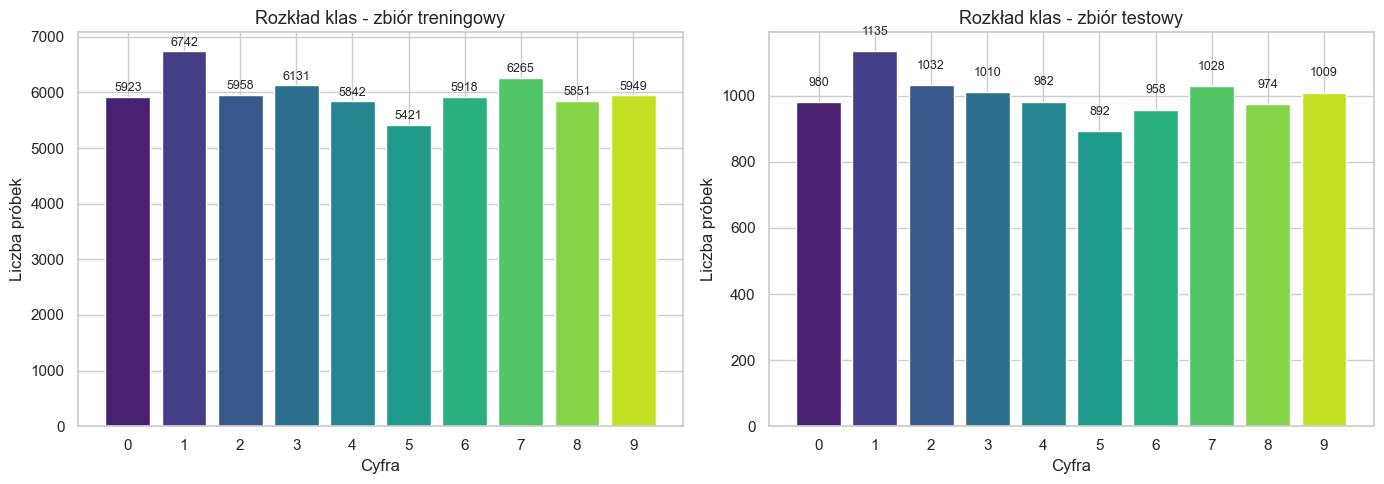

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('viridis', 10)

axes[0].bar(unique_train, counts_train, color=colors)
axes[0].set_title('Rozkład klas - zbiór treningowy', fontsize=13)
axes[0].set_xlabel('Cyfra')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_xticks(range(10))
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

axes[1].bar(unique_test, counts_test, color=colors)
axes[1].set_title('Rozkład klas - zbiór testowy', fontsize=13)
axes[1].set_xlabel('Cyfra')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_xticks(range(10))
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1.2 Przykładowe obrazy ze zbioru

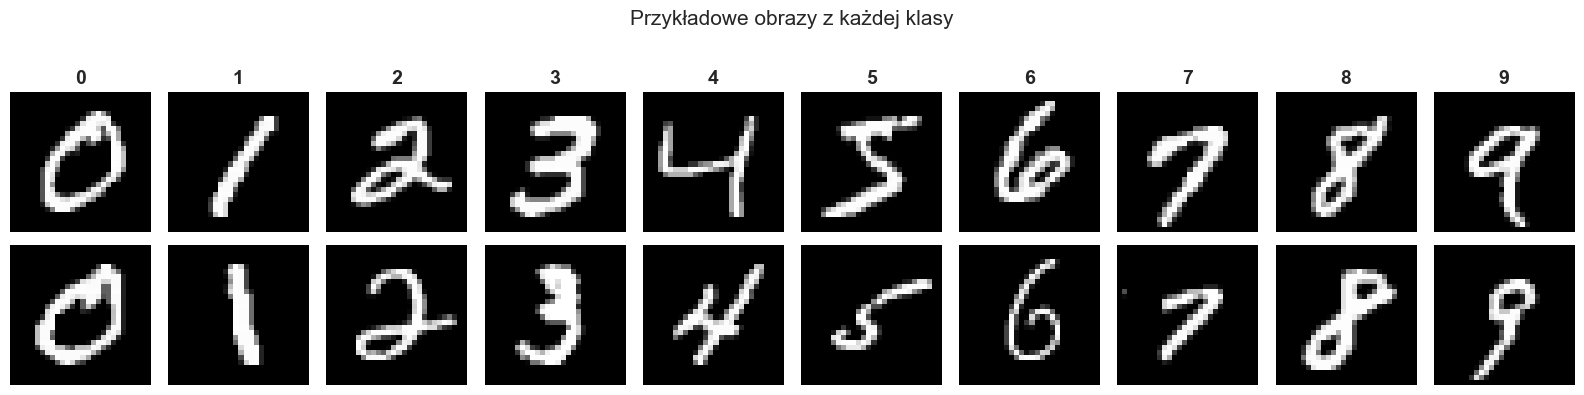

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    idxs = np.where(y_train == digit)[0]
    for row in range(2):
        ax = axes[row, digit]
        ax.imshow(x_train[idxs[row]], cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=14, fontweight='bold')
fig.suptitle('Przykładowe obrazy z każdej klasy', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Statystyki pikseli

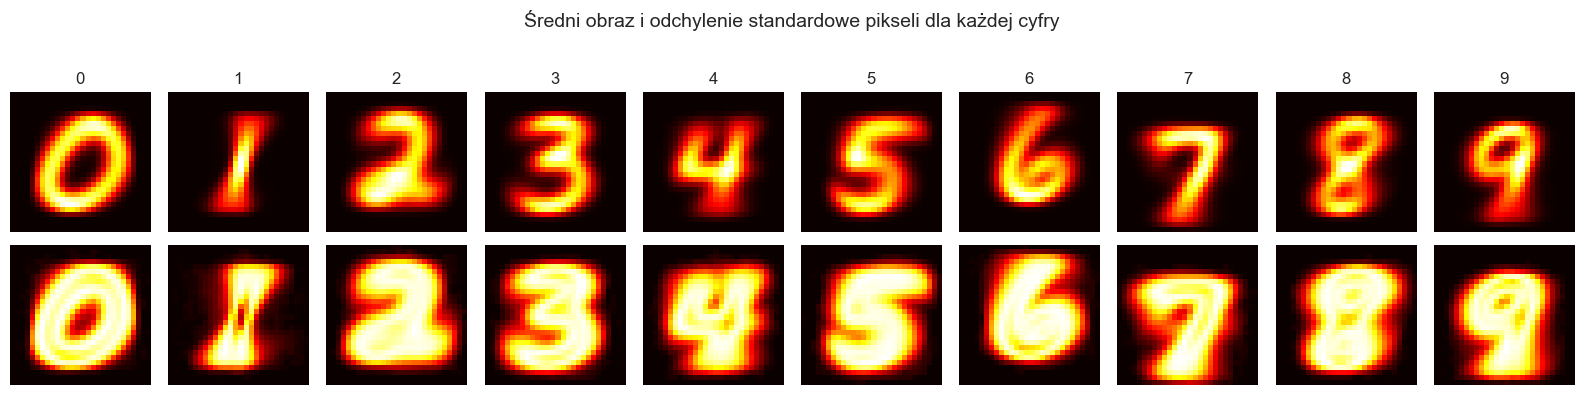

In [6]:
# Średni obraz i odchylenie standardowe pikseli
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    digit_imgs = x_train[y_train == digit]
    mean_img = digit_imgs.mean(axis=0)
    std_img = digit_imgs.std(axis=0)
    
    axes[0, digit].imshow(mean_img, cmap='hot')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(str(digit), fontsize=12)
    
    axes[1, digit].imshow(std_img, cmap='hot')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Średnia', fontsize=11)
axes[1, 0].set_ylabel('Odch. std.', fontsize=11)
fig.suptitle('Średni obraz i odchylenie standardowe pikseli dla każdej cyfry', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

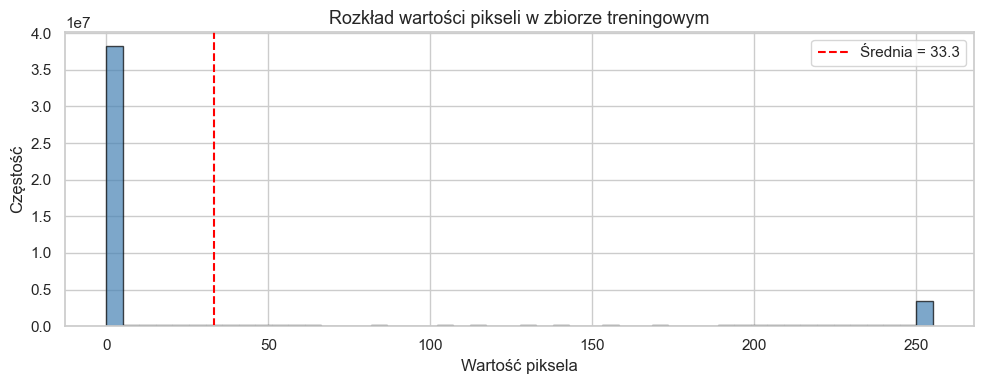

Procent pikseli niezerowych: 19.1%
Procent pikseli zerowych (tło): 80.9%


In [7]:
# Rozkład wartości pikseli w zbiorze treningowym
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(x_train.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Rozkład wartości pikseli w zbiorze treningowym', fontsize=13)
ax.set_xlabel('Wartość piksela')
ax.set_ylabel('Częstość')
ax.axvline(x=x_train.flatten().mean(), color='red', linestyle='--', label=f'Średnia = {x_train.flatten().mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

nonzero_pct = (x_train > 0).sum() / x_train.size * 100
print(f"Procent pikseli niezerowych: {nonzero_pct:.1f}%")
print(f"Procent pikseli zerowych (tło): {100 - nonzero_pct:.1f}%")

---
# 2. Analiza istotności cech (pikseli)

W przypadku obrazów piksele stanowią cechy wejściowe modelu. Zamiast klasycznych metod feature selection (jak SelectKBest),
które zakładają cechy tabelaryczne, stosujemy podejście oparte na analizie wariancji pikseli.

### Metoda: Analiza wariancji pikseli między klasami
Obliczamy średni obraz dla każdej klasy, a następnie wariancję tych średnich obrazów po klasach.
Piksele o wysokiej wariancji międzyklasowej to te, które najbardziej różnicują cyfry - są więc najistotniejszymi cechami.
Piksele o niskiej wariancji (np. rogi obrazu) nie wnoszą informacji do klasyfikacji.

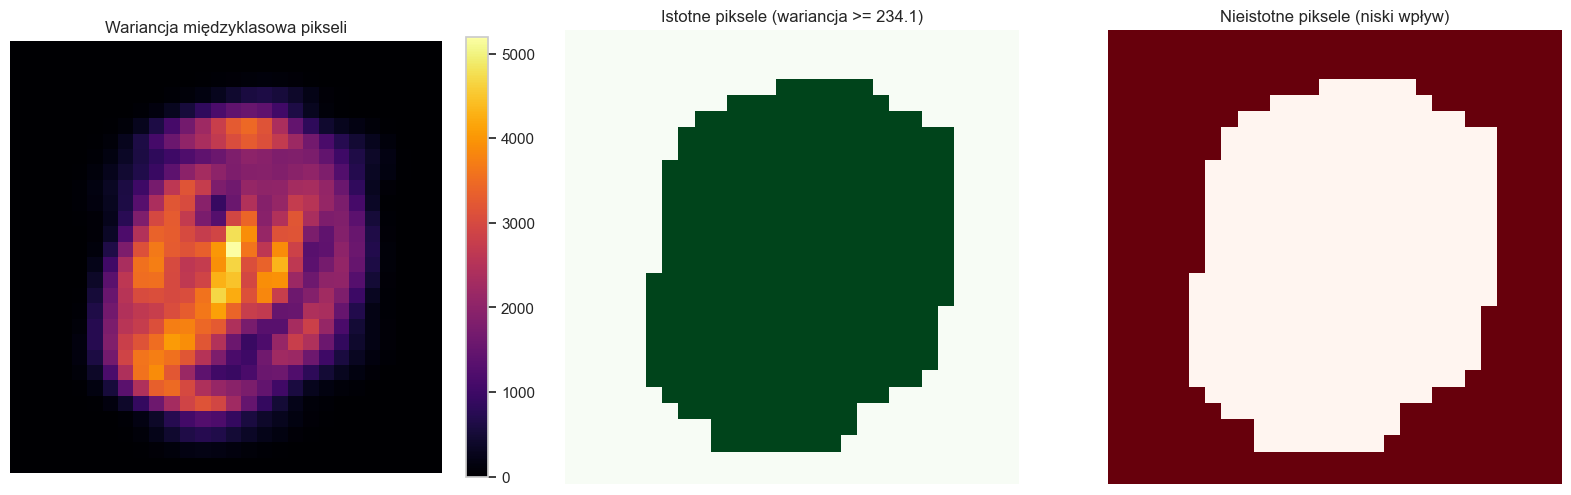

Liczba istotnych pikseli: 359 / 784 (45.8%)
Liczba nieistotnych pikseli: 425 / 784 (54.2%)


In [8]:
# Obliczenie średnich obrazów dla każdej klasy
class_means = np.array([x_train[y_train == d].mean(axis=0) for d in range(10)])

# Wariancja międzyklasowa - dla każdego piksela liczymy wariancję po 10 średnich
inter_class_variance = class_means.var(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mapa wariancji
im0 = axes[0].imshow(inter_class_variance, cmap='inferno')
axes[0].set_title('Wariancja międzyklasowa pikseli', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Maska: piksele powyżej mediany wariancji
threshold = np.median(inter_class_variance[inter_class_variance > 0])
important_mask = (inter_class_variance >= threshold).astype(float)
axes[1].imshow(important_mask, cmap='Greens')
axes[1].set_title(f'Istotne piksele (wariancja >= {threshold:.1f})', fontsize=12)
axes[1].axis('off')

# Nieistotne piksele (rogi, krawędzie)
unimportant_mask = (inter_class_variance < threshold).astype(float)
axes[2].imshow(unimportant_mask, cmap='Reds')
axes[2].set_title('Nieistotne piksele (niski wpływ)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

n_important = int(important_mask.sum())
n_total = 28 * 28
print(f"Liczba istotnych pikseli: {n_important} / {n_total} ({n_important/n_total*100:.1f}%)")
print(f"Liczba nieistotnych pikseli: {n_total - n_important} / {n_total} ({(n_total - n_important)/n_total*100:.1f}%)")

In [9]:
# Ranking pikseli wg wariancji międzyklasowej
variance_flat = inter_class_variance.flatten()
pixel_ranking = np.argsort(variance_flat)[::-1]

top_n = 20
print(f"Top {top_n} najistotniejszych pikseli (indeks, pozycja wiersz x kolumna, wariancja):")
print("-" * 55)
for rank, idx in enumerate(pixel_ranking[:top_n], 1):
    row, col = divmod(idx, 28)
    print(f"  {rank:>2}. Piksel [{row:>2}, {col:>2}]  (indeks {idx:>3})  wariancja = {variance_flat[idx]:.2f}")

Top 20 najistotniejszych pikseli (indeks, pozycja wiersz x kolumna, wariancja):
-------------------------------------------------------
   1. Piksel [13, 14]  (indeks 378)  wariancja = 5200.81
   2. Piksel [12, 14]  (indeks 350)  wariancja = 4776.06
   3. Piksel [16, 13]  (indeks 461)  wariancja = 4678.83
   4. Piksel [14, 14]  (indeks 406)  wariancja = 4660.99
   5. Piksel [15, 14]  (indeks 434)  wariancja = 4488.41
   6. Piksel [14, 17]  (indeks 409)  wariancja = 4331.34
   7. Piksel [15, 13]  (indeks 433)  wariancja = 4298.57
   8. Piksel [16, 14]  (indeks 462)  wariancja = 4229.58
   9. Piksel [17, 13]  (indeks 489)  wariancja = 4122.39
  10. Piksel [19, 10]  (indeks 542)  wariancja = 4047.98
  11. Piksel [13, 13]  (indeks 377)  wariancja = 4020.39
  12. Piksel [15, 17]  (indeks 437)  wariancja = 3946.40
  13. Piksel [14, 13]  (indeks 405)  wariancja = 3923.16
  14. Piksel [19, 11]  (indeks 543)  wariancja = 3920.60
  15. Piksel [15, 16]  (indeks 436)  wariancja = 3911.72
  16. Pik

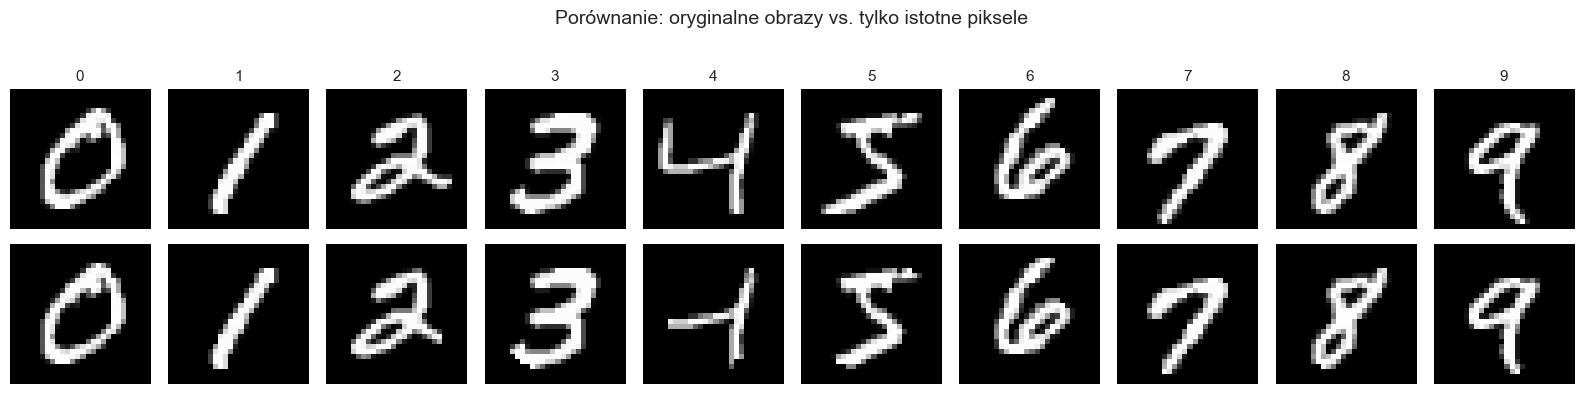

In [10]:
# Wizualizacja: efekt usunięcia nieistotnych pikseli
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    original = x_train[idx]
    masked = original * important_mask
    
    axes[0, digit].imshow(original, cmap='gray')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(str(digit), fontsize=11)
    
    axes[1, digit].imshow(masked, cmap='gray')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Oryginał', fontsize=11)
axes[1, 0].set_ylabel('Po masce', fontsize=11)
fig.suptitle('Porównanie: oryginalne obrazy vs. tylko istotne piksele', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### 3. Augmentacja Danych

Aby uodpornić model na niedoskonałości pisma ręcznego oraz zwiększyć ogólną zdolność generalizacji sieci, wprowadzono dwie formy augmentacji danych treningowych:
1. **Obrót**: Każdy obraz jest obracany o określony kąt z zakresu od -20° do 20° z krokiem co 5°.
2. **Szum Gaussowski**: Do obrazów (zarówno oryginalnych, jak i obróconych) dodawany jest szum z rozkładu normalnego (std=20), imitujący niedokładności skanowania lub zabrudzenia tła.

Zastosowana logika generuje nowe przypadki dla każdego obrazka wejściowego:
- Dodanie samego szumu gaussowskiego do oryginału.
- Wygenerowanie wariantów obróconych.
- Dodanie szumu do wygenerowanych wariantów obróconych.

Łącznie na każdy obraz powstaje: 1 (oryginał) + 1 (szum) + 8 (obroty) + 8 (obroty+szum) = 18 wariantów

Razem: 60 000 x 18 = 1 080 000 rekordów.

### 3.1 Przykłady augmentacji dla każdej cyfry

Poniższa wizualizacja pokazuje przykładowe modyfikacje dla każdej cyfry (0-9) ze zbioru danych. Prezentujemy kolejno:
1. Obraz oryginalny
2. Obraz obrócony o 20 stopni
3. Obraz z dodanym szumem gaussowskim (std=20)
4. Połączenie obu transformacji (obrót o 20 stopni + szum)

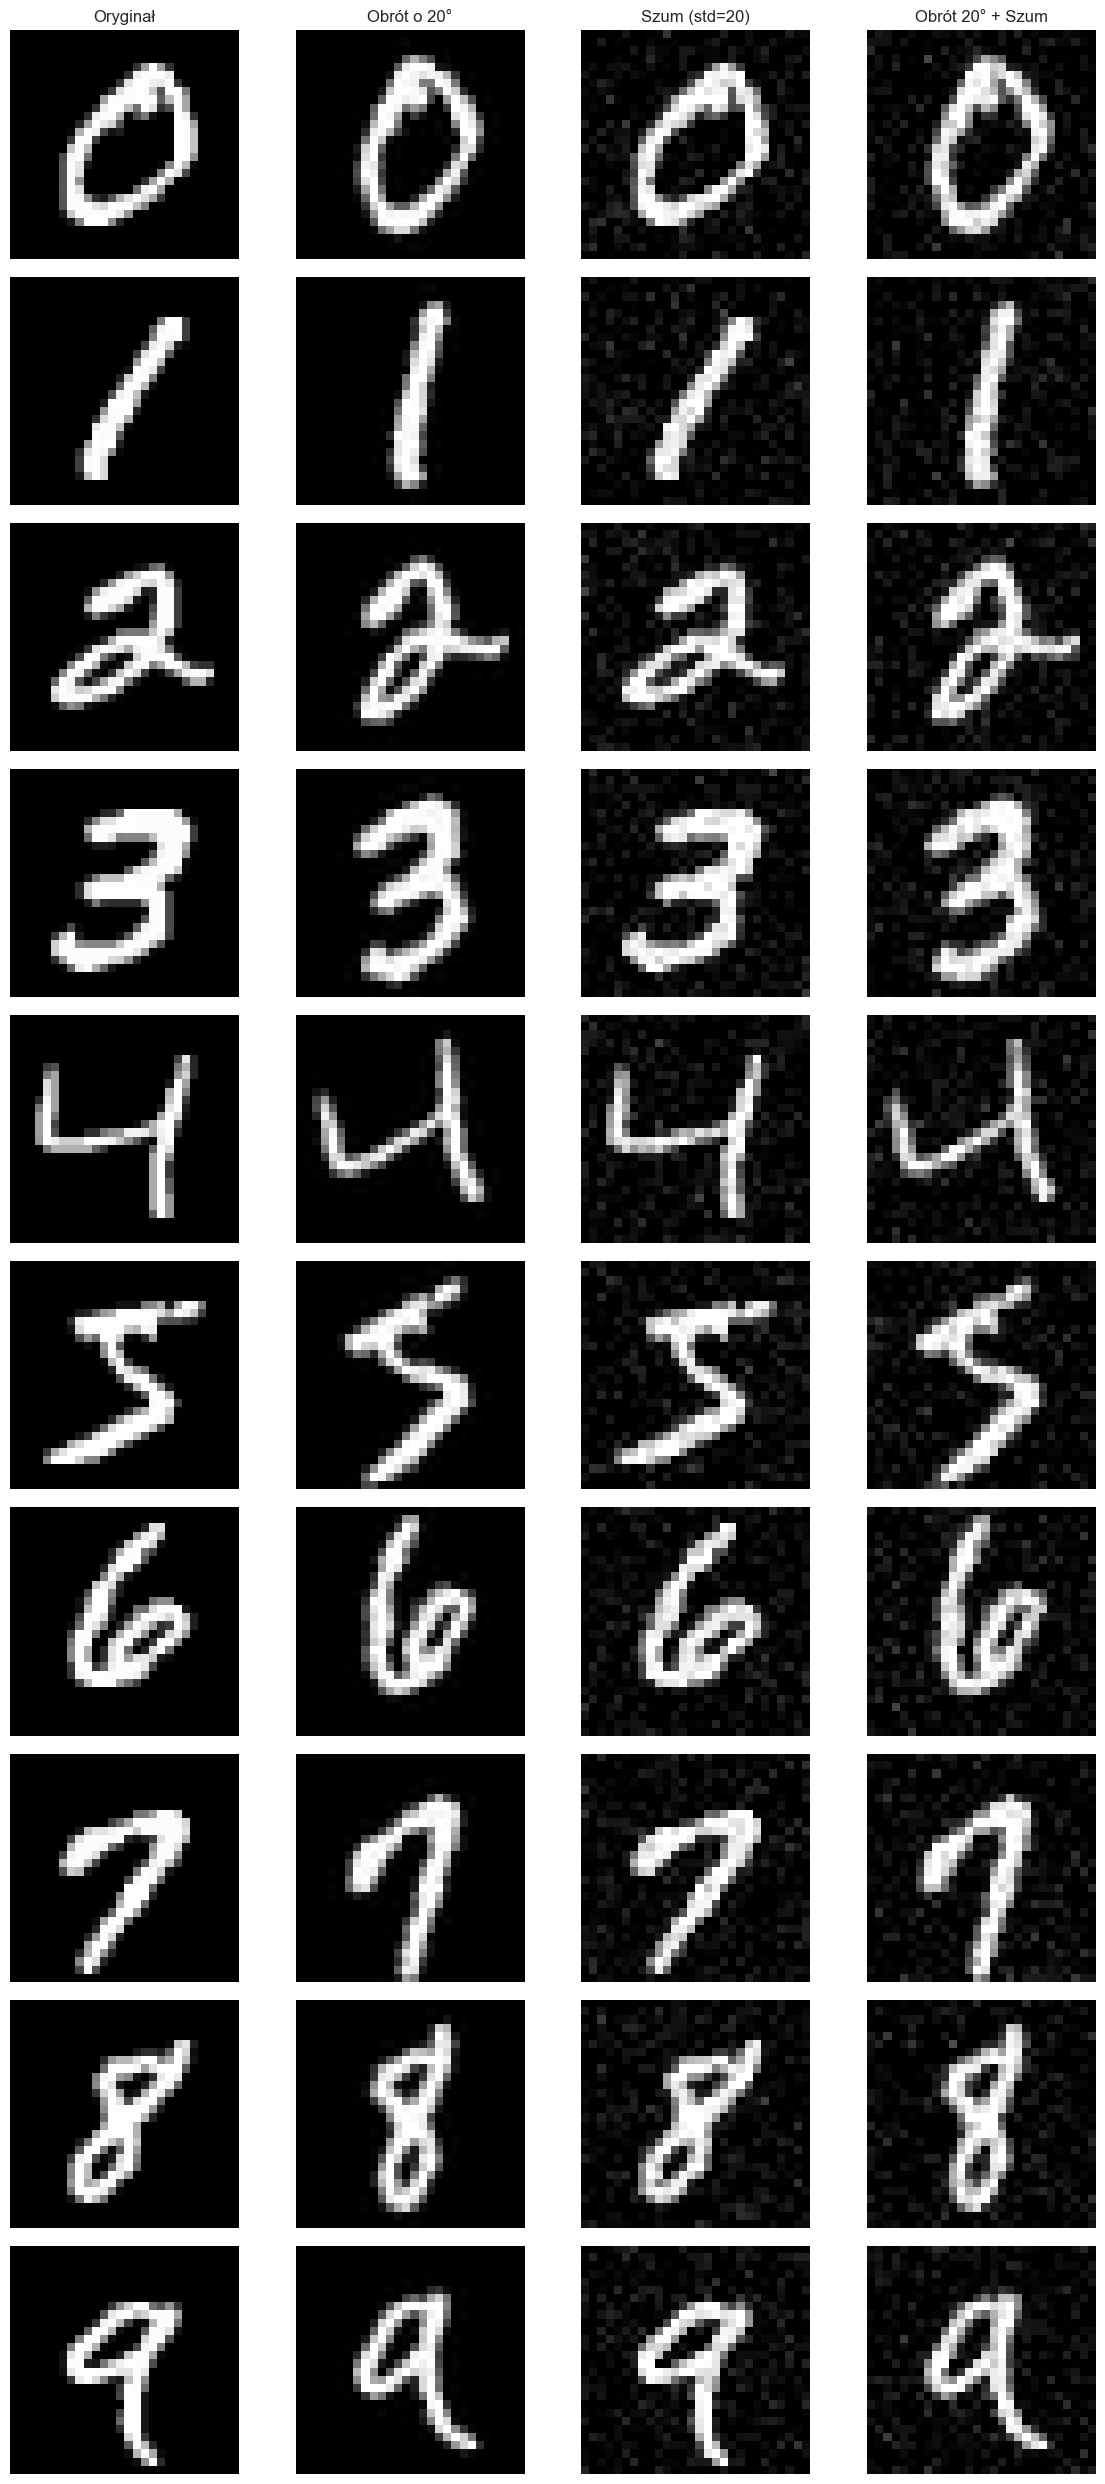

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate

# Przykładowe wizualizacje transformacji
NOISE_STD = 20.0

fig, axes = plt.subplots(10, 4, figsize=(12, 25))

samples = [x_train[y_train == i][0] for i in range(10)]

for i, img in enumerate(samples):
    # 1. Oryginał
    axes[i, 0].imshow(img, cmap='gray')
    if i == 0:
        axes[i, 0].set_title("Oryginał")
    axes[i, 0].axis('off')
    
    # 2. Obrót
    img_rot = rotate(img, 20, axes=(0,1), reshape=False, mode='constant', cval=0.0)
    axes[i, 1].imshow(img_rot, cmap='gray')
    if i == 0:
        axes[i, 1].set_title("Obrót o 20°")
    axes[i, 1].axis('off')
    
    # 3. Szum
    noise = np.random.normal(loc=0.0, scale=NOISE_STD, size=img.shape)
    img_noised = img + noise
    img_noised = np.clip(img_noised, 0, 255).astype(np.uint8)
    axes[i, 2].imshow(img_noised, cmap='gray')
    if i == 0:
        axes[i, 2].set_title(f"Szum (std={int(NOISE_STD)})")
    axes[i, 2].axis('off')
    
    # 4. Obrót + Szum
    noise_rot = np.random.normal(loc=0.0, scale=NOISE_STD, size=img_rot.shape)
    img_rot_noised = img_rot + noise_rot
    img_rot_noised = np.clip(img_rot_noised, 0, 255).astype(np.uint8)
    axes[i, 3].imshow(img_rot_noised, cmap='gray')
    if i == 0:
        axes[i, 3].set_title("Obrót 20° + Szum")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

---
# 4. Eksperymenty

Poniżej przedstawiono 3 gałęzie eksperymentów.

**Mierniki jakościowe:**
- **Accuracy** - ogólna dokładność klasyfikacji
- **Precision** - precyzja uśredniona po klasach
- **Recall** - czułość uśredniona po klasach
- **F1-score** - średnia harmoniczna precision i recall

## 4.1 Gałąź 1 - Keras CNN bez augmentacji

Zbiór treningowy: **60 000 obrazów** (oryginalny MNIST, bez augmentacji).

Kod treningowy: `notebooks/recognition_without_augmentation.ipynb`


### Tabela eksperymentów - Keras CNN bez augmentacji
<table border="1">
  <thead>
    <tr>
      <th>Nr</th>
      <th>Conv1 filtry</th>
      <th>Conv1 kernel</th>
      <th>Conv2 filtry</th>
      <th>Conv2 kernel</th>
      <th>Dense neurony</th>
      <th>Dropout</th>
      <th>Optimizer</th>
      <th>Learning rate</th>
      <th>Batch size</th>
      <th>Epochs</th>
      <th>Loss func</th>
      <th>Loss</th>
      <th>Accuracy</th>
      <th>Precision (macro avg)</th>
      <th>Recall (macro avg)</th>
      <th>F1-score (macro avg)</th>
      <th>Uwagi</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td><td>8</td><td>2</td><td>16</td><td>2</td><td>64</td><td>0</td><td>sgd</td><td>domyślny</td><td>32</td><td>5</td><td>SparseCatCE</td><td>0.11444105207920074</td><td> 96.44</td><td>0.96</td><td>0.96</td><td>0.96</td>
      <td>Pierwsze uruchomienie</td>
    </tr>
    <tr>
      <td>2</td><td>4</td><td>2</td><td>8</td><td>2</td><td>64</td><td>0</td><td>sgd</td><td>domyślny</td><td>32</td><td>5</td><td>SparseCatCE</td><td>0.09538538008928299</td><td>96.98</td><td>0.97</td><td>0.97</td><td>0.97</td>
      <td>Nieznaczna poprawa po zwiększeniu ilości filtrów w warstwach splotowych - 5 epok wydaje się być dużo - pod koniec uczenia accuracy na zbiorze testowym minimalnie spadło</td>
    </tr>
    <tr>
      <td>3</td><td>4</td><td>3</td><td>8</td><td>3</td><td>64</td><td>0</td><td>sgd</td><td>domyślny</td><td>32</td><td>3</td><td>SparseCatCE</td><td>0.0865</td><td>0.9740</td><td>0.97</td><td>0.97</td><td>0.97</td>
      <td>Zwiększenie rozmiaru filtrów, oraz zmniejszenie ilości epok wpłyneło minimalnie pozytywnie na dokładność i spadek loss'u</td>
    </tr>
    <tr>
      <td>4</td><td>4</td><td>3</td><td>8</td><td>3</td><td>64</td><td>0</td><td>adam</td><td>domyślny</td><td>32</td><td>3</td><td>SparseCatCE</td><td>0.04315488040447235</td><td>98.59</td><td>0.99</td><td>0.99</td><td>0.99</td>
      <td>Zmiana optymalizatora na adam bardzo pozytywnie wpłynęła na spadek lossu i zwiększenie pozostałych mierkników</td>
    </tr>
    <tr>
      <td>5</td><td>4</td><td>3</td><td>8</td><td>3</td><td>64</td><td>0</td><td>adam</td><td>domyślny</td><td>32</td><td>2</td><td>SparseCatCE</td><td>0.05153736099600792</td><td>98.33</td><td>0.98</td><td>0.98</td><td>0.98</td>
      <td>Zmniejszenie epok do dwóch nieznacznie pogorszyło wyniki</td>
    </tr>
    <tr>
      <td>6</td><td>4</td><td>3</td><td>8</td><td>3</td><td>64</td><td>0.5</td><td>adam</td><td>domyślny</td><td>32</td><td>2</td><td>SparseCatCE</td><td>0.06219949945807457</td><td>97.93</td><td>0.98</td><td>0.98</td><td>0.98</td>
      <td>Agresywny dropout (wyłączenie aż połowy neuronów z warstwy Dense) minimalnie obniżył accuracy</td>
    </tr>
    <tr>
      <td>7</td><td>4</td><td>3</td><td>8</td><td>3</td><td>64</td><td>0.3</td><td>adam</td><td>domyślny</td><td>32</td><td>2</td><td>SparseCatCE</td><td>06083596870303154</td><td>98.14</td><td>0.98</td><td>0.98</td><td>0.98</td>
      <td>Decyzja o ustawieniu dropout na 0.3 w celu zabezpiezenia się przed przeuczaniem się sieci</td>
    </tr>
    <tr>
      <td>8</td><td>4</td><td>3</td><td>8</td><td>3</td><td>64</td><td>0.3</td><td>adam</td><td>domyślny</td><td>32</td><td>2</td><td>SparseCatCE</td><td>06083596870303154</td><td>98.14</td><td>0.98</td><td>0.98</td><td>0.98</td>
      <td>Decyzja o ustawieniu dropout na 0.3 w celu zabezpiezenia się przed przeuczaniem się sieci</td>
    </tr>
    <tr>
      <td>9</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>10</td><td>32</td><td>3</td><td>64</td><td>3</td><td>64</td><td>0.5</td><td>adam</td><td>domyślny</td><td>32</td><td>4</td><td>SparseCatCE</td><td>0.0408</td><td>0.9875</td><td>0.99</td><td>0.99</td><td>0.99</td>
      <td>Baseline - model z notebooks/recognition_without_augmentation.ipynb</td>
    </tr>
  </tbody>
</table>

## 4.2 Gałąź 2 - Keras CNN z augmentacją danych

Zbiór treningowy: **1 080 000 obrazów** (MNIST + augmentacja: rotacje + szum gaussowski).

Kod treningowy: `notebooks/recognition_with_augmentation.ipynb`


### Tabela eksperymentów - Keras CNN z augmentacją
<table border="1">
  <thead>
    <tr>
      <th>Nr</th>
      <th>Conv1 filtry</th>
      <th>Conv1 kernel</th>
      <th>Conv2 filtry</th>
      <th>Conv2 kernel</th>
      <th>Dense neurony</th>
      <th>Dropout</th>
      <th>Optimizer</th>
      <th>Learning rate</th>
      <th>Batch size</th>
      <th>Epochs</th>
      <th>Loss func</th>
      <th>Augm. rotacje</th>
      <th>Augm. szum std</th>
      <th>Rozmiar zbioru</th>
      <th>Loss</th>
      <th>Accuracy</th>
      <th>Precision (macro)</th>
      <th>Recall (macro)</th>
      <th>F1-score (macro)</th>
      <th>Uwagi</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
    </tr>
    <tr>
      <td>2</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>3</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>4</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>5</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>6</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>7</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>8</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>9</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>10</td>
      <td>32</td>
      <td>3</td>
      <td>64</td>
      <td>3</td>
      <td>128</td>
      <td>0.3</td>
      <td>adam</td>
      <td>domyślny</td>
      <td>32</td>
      <td>1</td>
      <td>SparseCatCE</td>
      <td>[-20..20] co 5 deg</td>
      <td>10.0</td>
      <td>1 080 000</td>
      <td>0.0231</td>
      <td>0.9929</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>Baseline - model z notebooks/recognition_with_augmentation.ipynb</td>
    </tr>
  </tbody>
</table>

## 4.3 Gałąź 3 - Własna implementacja CNN (my_cnn)

Sieć napisana od zera w NumPy z własną implementacją:
- Warstw: `Convolution2D`, `MaxPooling2D`, `Dense`, `Flatten`, `Rescaling`, `Input`
- Funkcji aktywacji: `ReLU`, `Softmax`
- Funkcji straty: `CrossEntropy`
- Optymalizatora: `SGD`

Zbiór treningowy: **60 000 obrazów** (oryginalny MNIST).

Kod treningowy: `notebooks/mycnn.ipynb`



### Tabela eksperymentów - Własna implementacja CNN
<table border="1">
  <thead>
    <tr>
      <th>Nr</th>
      <th>Conv1 filtry</th>
      <th>Conv1 kernel</th>
      <th>Conv2 filtry</th>
      <th>Conv2 kernel</th>
      <th>Dense neurony</th>
      <th>Dropout</th>
      <th>Optimizer</th>
      <th>Learning rate</th>
      <th>Batch size</th>
      <th>Epochs</th>
      <th>Loss func</th>
      <th>Loss</th>
      <th>Accuracy</th>
      <th>Precision (macro)</th>
      <th>Recall (macro)</th>
      <th>F1-score (macro)</th>
      <th>Uwagi</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
    </tr>
    <tr>
      <td>2</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>3</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>4</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>5</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>6</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>7</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>8</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>9</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>10</td>
      <td>8</td>
      <td>3</td>
      <td>16</td>
      <td>3</td>
      <td>64</td>
      <td>brak</td>
      <td>sgd</td>
      <td>0.05</td>
      <td>128</td>
      <td>3</td>
      <td>CrossEntropy</td>
      <td>0.1294</td>
      <td>0.9573</td>
      <td>0.96</td>
      <td>0.96</td>
      <td>0.96</td>
      <td>Baseline - parametry z mycnn.ipynb</td>
    </tr>
  </tbody>
</table>

---
# 5. Porównanie wyników między gałęziami

Zestawienie najlepszych wyników z każdej gałęzi eksperymentów.
<table>
  <thead>
    <tr>
      <th>Gałąź</th>
      <th>Najlepszy Exp. Nr</th>
      <th>Accuracy</th>
      <th>Precision (macro)</th>
      <th>Recall (macro)</th>
      <th>F1 (macro)</th>
      <th>Loss</th>
      <th>Zbiór treningowy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1. Keras bez augmentacji</td>
      <td>1</td>
      <td>0.9875</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.0408</td>
      <td>60 000</td>
    </tr>
    <tr>
      <td>2. Keras z augmentacją</td>
      <td>1</td>
      <td>0.9929</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.0231</td>
      <td>1 080 000</td>
    </tr>
    <tr>
      <td>3. Własne CNN</td>
      <td>1</td>
      <td>0.9573</td>
      <td>0.96</td>
      <td>0.96</td>
      <td>0.96</td>
      <td>0.1294</td>
      <td>60 000</td>
    </tr>
  </tbody>
</table>

---
# 6. Obserwacje (interpretacja wyników)

*TODO: Uzupełnij po przeprowadzeniu wszystkich eksperymentów.*

W tej sekcji należy opisać zaobserwowane zależności, np.:
- Jak zmiana liczby filtrów Conv wpływa na accuracy?
- Jak zmiana dropout wpływa na overfitting?
- Jak augmentacja danych wpłynęła na wyniki?
- Jak wypada własna implementacja CNN vs Keras?
- Które cyfry są najczęściej mylone?

---
# 7. Wnioski końcowe
